# Autocalibration of the backward detectors
This is the routine to calibrate the backward detectors of the GFAS101 

It uses the following datasets: 
- treated PbP data from GFASLabExperiments2024/cal_beads  
- scale factors in PbP_processing/detector_scaling_factors

Sub-routines needed:
- PbP_processing/GFAS101_processing


author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 


Last modified June 26 2026

In [1]:
import sys  
from pathlib import Path
import numpy as np
import pandas as pd
import glob2
import glob, os
import os
from io import BytesIO
import datetime as dt
import calendar
from pandas.errors import EmptyDataError
from scipy.ndimage import shift
import scipy
import metpy
from metpy.calc import wind_components,wind_speed,wind_direction
from metpy.units import units
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors
import seaborn as sns 
import shapely 
import matplotlib.ticker as ticker
import matplotlib 
import PyMieScatt  as pms
from scipy.stats import linregress
from scipy.stats import chisquare
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from scipy.stats import ks_2samp

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


project_dir = Path.cwd().parent
sys.path.append(str(project_dir))
from PbP_processing.GFAS101_processing import *
from GFAS_reading.GFAS101_read_in import *


## Prep stuff for the fitting

### read in 

In [3]:
wick = pd.read_csv('/home/leha7253/data/LabExperiments/maxi.csv', index_col=0)
wick = qual_filter(wick)
wick = attenuation(wick)
wick = sizing_model(wick)

### calculate theoretical values and do the polynominal regression for S and P detectors

In [5]:
## P pol and Spol scattering cross section vs Dp for different m
def sct_SLSR(m, diam, wvl, ang):
    sc_L = np.full((len(diam)), np.nan)  # output vector
    sc_R = np.full((len(diam)), np.nan)  # output vector
    sc_TOT = np.full((len(diam)), np.nan)  # output vector
    angle_res = (ang[-1]-ang[0])/30
    for k1, d in enumerate(diam):
        x = d * np.pi / wvl  # size parameter
        theta, SL, SR, SU = pms.ScatteringFunction(m=m, wavelength=wvl, diameter=d, nMedium=1.0,  minAngle=ang[0], maxAngle=ang[-1], angularResolution= angle_res)
        sc_l = x ** (-2) * np.trapz((SL) * np.sin(theta), theta)
        sc_r = x ** (-2) * np.trapz((SR) * np.sin(theta), theta)
        sc_tot =x ** (-2) * np.trapz((SL+SR) * np.sin(theta), theta)
        sc_L[k1] = sc_l * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_R[k1] = sc_r * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_TOT[k1] = sc_tot * 0.25 * np.pi * (d * 1e-9) **2
        sc_L = sc_L 
        sc_R = sc_R 
        sc_TOT = sc_TOT 
    return sc_L, sc_R, sc_TOT

In [6]:
# compute theoretical scattering cross section for forward and backward scattering

diam = np.arange(0.7, 50.1, 0.05) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm
r550 =  1.33+0j

ang_fw = np.linspace(3.8, 20, 30)  
ang_bw = np.linspace(168, 176.5, 30) 

sc_L, sc_R, sc_tot = sct_SLSR(r550, diam, wvl, ang_fw)
model_fwd = [sc_L, sc_R, sc_tot]

sc_L, sc_R, sc_tot = sct_SLSR(r550, diam, wvl, ang_bw)
model_bwd = [sc_L, sc_R, sc_tot]

model_fwd = pd.DataFrame(model_fwd, index = ['S', 'P', 'tot']).T
model_bwd = pd.DataFrame(model_bwd, index = ['S', 'P', 'tot']).T
model_fwd.index = diam/1000
model_bwd.index = diam/1000
model_bwd.index = model_bwd.index.round(2)
model_fwd.index = model_fwd.index.round(2)
# right unit
model_fwd = model_fwd*10**4
model_bwd = model_bwd*10**4

#### regression fitting

In [7]:

#### S-pol fit ##########
#X is the independent variable (bivariate in this case)
X_S = pd.DataFrame(np.log10(model_bwd['S']))

#vector is the dependent data
vector_S = np.log10(model_bwd.index)

#predict is an independent variable for which we'd like to predict the value
predictS= np.log10(np.linspace(4.5e-12, 2.3e-8, 200).reshape(-1, 1))

#generate a model of polynomial features
poly_S = PolynomialFeatures(degree=2)

#transform the x data for proper fitting (for single variable type it returns,[1,x,x**2])
X_S = poly_S.fit_transform(X_S)

#transform the prediction to fit the model type
predict_S = poly_S.fit_transform(predictS)

#generate the regression object
clf_S = linear_model.LinearRegression()
#preform the actual regression
clf_S.fit(X_S, vector_S)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:

#### P-pol fit ##########
#X is the independent variable (bivariate in this case)
X_P = pd.DataFrame(np.log10(model_bwd['P']))

#vector is the dependent data
vector_P = np.log10(model_bwd.index)

#predict is an independent variable for which we'd like to predict the value
predictP= np.log10(np.linspace(4.8e-12, 3.65e-8, 200).reshape(-1, 1))

#generate a model of polynomial features
poly_P = PolynomialFeatures(degree=2)

#transform the x data for proper fitting (for single variable type it returns,[1,x,x**2])
X_P = poly_P.fit_transform(X_P)

#transform the prediction to fit the model type
predict_P = poly_P.fit_transform(predictP)

#generate the regression object
clf_P = linear_model.LinearRegression()
#preform the actual regression
d = clf_P.fit(X_P, vector_P)

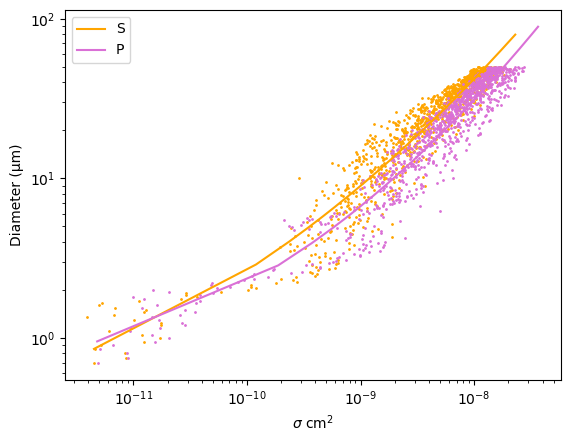

In [9]:
plt.scatter(model_bwd['S'], model_bwd.index,s=1, color ='orange')
plt.plot(10**predictS,10**clf_S.predict(predict_S), color ='orange', label = 'S')

plt.scatter(model_bwd['P'], model_bwd.index,s=1, color ='orchid')
plt.plot(10**predictP,10**clf_P.predict(predict_P), color ='orchid', label = 'P')
'''plt.ylim(0,12)
plt.xlim(1e-12,0.5e-8)'''
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\sigma$ cm$^2$')
plt.ylabel('Diameter (µm)')
plt.legend()
plt.show()

## Autocalibration II: Fit backward detectors to forward detector in log log space 

$log10(\sigma_S) = a \cdot log10(\sigma_F) + b$ \
$ \sigma_S = c_S I_S $ \
$ \sigma_F = c_F I_F $ \
$ log10(c_S I_S) = a \cdot log10(c_F I_F )+b$ \
$ log10(c_S) = (a \cdot log10(c_F I_F )+b)-log10(I_S)$

In [14]:
tgb = pd.DataFrame({
    'forward': model_fwd['tot'],
    'S': model_bwd['S'],
    'P': model_bwd['P']
})

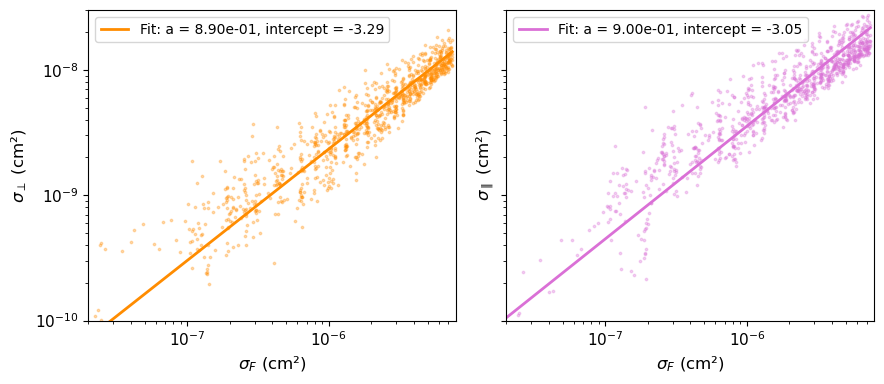

In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base size
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
})

fig, ax = plt.subplots(1,2, figsize=(9, 4), sharey = True)
ax[0].scatter((tgb['forward']), tgb['S'], color = 'darkorange', alpha = 0.3, s = 3)
# add linear regression line
slope_s, intercept_s, r_value_s, p_value_s, std_err_s= linregress(np.log10((tgb['forward'])), np.log10(tgb['S']))
x = np.linspace((tgb['forward']).min(), (tgb['forward']).max(), 100)
y = 10**(intercept_s + slope_s * np.log10(x))
ax[0].plot(x, y, color='darkorange', linewidth=2, label=f'Fit: a = {slope_s:.2e}, intercept = {intercept_s:.2f}')
# plot standard error as shaded area
#y_err = 10**(intercept_s + slope_s * np.log10(x)) * std_err_s
#ax[0].fill_between(x, y - y_err, y + y_err, color='darkorange', alpha=0.2, label=f'Standard error: {std_err_s:.2e}')


ax[1].scatter((tgb['forward']), tgb['P'], color = 'orchid', alpha = 0.3, s = 3)
# add linear regression line
slope_p, intercept_p, r_value_p, p_value_p, std_err_p = linregress(np.log10((tgb['forward'])), np.log10(tgb['P']))
x = np.linspace((tgb['forward']).min(), (tgb['forward']).max(), 100)
y = 10**(intercept_p + slope_p * np.log10(x))
ax[1].plot(x, y, color='orchid', linewidth=2, label=f'Fit: a = {slope_p:.2e}, intercept = {intercept_p:.2f}')
# plot standard error as shaded area
#y_err = 10**(intercept_p + slope_p * np.log10(x)) * std_err_p
#plt.fill_between(x, y - y_err, y + y_err, color='orchid', alpha=0.2, label=f'Standard error: {std_err_p:.2e}')

ax[0].legend(loc = 'upper left', fontsize = 10)
ax[1].legend(loc = 'upper left', fontsize = 10)
ax[0].set(xscale='log', yscale='log', xlabel='$\sigma_F$ (cm²)', ylabel='$\sigma_{\perp}$ (cm²)', xlim = (0.2*10**-7,7.9*10**-6), ylim=(0.1e-9,3e-8))
ax[1].set(xscale='log', yscale='log', xlabel='$\sigma_F$ (cm²)', ylabel='$\sigma_{\parallel}$ (cm²)', xlim = (0.2*10**-7,7.9*10**-6), ylim=(0.1e-9,3e-8))
plt.tight_layout()
#plt.savefig('backscatter_linearrelationship.png', dpi = 300)

### apply to our sample data

In [19]:
scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0)

In [17]:
idx = wick[wick['S Peak']>0].index.intersection(wick[wick['P Peak']>0].index)

In [20]:
c_s = 10**((slope_s*np.log10(wick.loc[idx, 'Sizer Peak']*scale_factors['forward'].values)+intercept_s) - np.log10(wick.loc[idx, 'S Peak']))
c_p = 10**((slope_p*np.log10(wick.loc[idx, 'Sizer Peak']*scale_factors['forward'].values)+intercept_p) - np.log10(wick.loc[idx, 'P Peak']))
c_p_described = c_p.describe()
c_s_described = c_s.describe()

In [21]:
# find mode of the distributions
# use only 99th percentile for upper bound to avoid outliers
c_p = c_p[c_p < c_p.quantile(0.99)]
c_s = c_s[c_s < c_s.quantile(0.99)]

In [22]:
from scipy.stats import gaussian_kde
def mode_kde(x):
    kde = gaussian_kde(x)
    grid = np.linspace(x.min(), 4e-11, 500)
    return grid[np.argmax(kde(grid))]

mode_p = mode_kde(c_p)
mode_s = mode_kde(c_s)

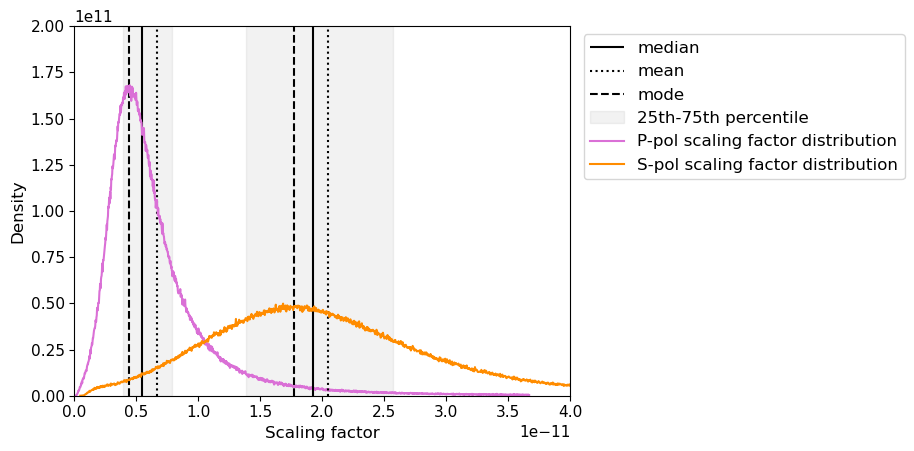

In [23]:
n,b = np.histogram(c_p, bins = 1500, density = True)
mid_b = b[:-1] + np.diff(b)/2
P = pd.Series(n, index = mid_b)

plt.vlines(c_p.median(), ymin=0, ymax = 2e11, color = 'k', linestyle = '-', label = f'median')
plt.vlines(c_p.mean(), ymin=0, ymax = 2e11, color = 'k', linestyle = ':', label = f'mean')
plt.vlines(mode_p, ymin=0, ymax = 2e11, color = 'k', linestyle = '--', label = f'mode')
# add quartiles and fill between them
plt.fill_betweenx(y =[0, 2e11], x1 = c_p.quantile(0.25), x2 = c_p.quantile(0.75), color = 'grey', alpha = 0.1, label = f'25th-75th percentile')
plt.plot(P.index, P.values, color = 'orchid', label = f'P-pol scaling factor distribution')


n,b = np.histogram(c_s, bins = 1500, density = True)
mid_b = b[:-1] + np.diff(b)/2
S = pd.Series(n, index = mid_b)

plt.vlines(c_s.median(), ymin=0, ymax = 2e11, color = 'k', linestyle = '-',)
plt.vlines(c_s.mean(), ymin=0, ymax = 2e11, color = 'k', linestyle = ':', )
plt.vlines(mode_s, ymin=0, ymax = 2e11, color = 'k', linestyle = '--',)
# add quartiles and fill between them
plt.fill_betweenx(y =[0, 2e11], x1 = c_s.quantile(0.25), x2 = c_s.quantile(0.75), color = 'grey', alpha = 0.1, )
plt.plot(S.index, S.values, color = 'darkorange', label = f'S-pol scaling factor distribution')


plt.xlim(0, 4e-11)
plt.ylim(0, 2e11)
plt.xlabel('Scaling factor')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

### scale testing via r_pol and F/B

In [24]:
S_peak =wick.loc[idx, 'S Peak']
P_peak =wick.loc[idx, 'P Peak']


meanS = S_peak*c_s_described['mean']
medianS = S_peak*c_s_described['50%']
modeS = S_peak*S.idxmax()

meanP = P_peak*c_p_described['mean']
medianP = P_peak*c_p_described['50%']
modeP = P_peak*P.idxmax()

r_pol_mean  = pd.DataFrame([(meanS-meanP)/(meanS+meanP), wick.loc[idx,'Diameter']], index = ['r_pol', 'Diameter']).T
r_pol_median  = pd.DataFrame([(medianS-medianP)/(medianS+medianP), wick.loc[idx,'Diameter']], index = ['r_pol', 'Diameter']).T
r_pol_mode = pd.DataFrame([(modeS-modeP)/(modeS+modeP), wick.loc[idx,'Diameter']], index = ['r_pol', 'Diameter']).T

FB_mean  = pd.DataFrame([wick.loc[idx,'scaled Sizer Peak']/(meanS+meanP), wick.loc[idx,'Diameter']], index = ['F/B', 'Diameter']).T
FB_median  = pd.DataFrame([wick.loc[idx,'scaled Sizer Peak']/(medianS+medianP), wick.loc[idx,'Diameter']], index = ['F/B', 'Diameter']).T
FB_mode = pd.DataFrame([wick.loc[idx,'scaled Sizer Peak']/(modeS+modeP), wick.loc[idx,'Diameter']], index = ['F/B', 'Diameter']).T



In [25]:
theory_rpol= (tgb['S']-tgb['P'])/(tgb['S']+tgb['P'])
theory_FB = tgb['forward']/(tgb['S']+tgb['P'])

In [26]:
bins = np.arange(0,50.1,0.1)
r_pol_mean['binned'] = pd.cut(r_pol_mean['Diameter'], bins = bins, labels = bins[1:])
r_pol_median['binned'] = pd.cut(r_pol_median['Diameter'], bins = bins, labels = bins[1:])
r_pol_mode['binned'] = pd.cut(r_pol_mode['Diameter'], bins = bins, labels = bins[1:])

r_pol_mean = r_pol_mean.groupby('binned',observed = True).median()
r_pol_median = r_pol_median.groupby('binned',observed = True).median()
r_pol_mode = r_pol_mode.groupby('binned',observed = True).median()

In [27]:

bins = np.arange(0,50.1,0.1)
FB_mean['binned'] = pd.cut(FB_mean['Diameter'], bins = bins, labels = bins[1:])
FB_median['binned'] = pd.cut(FB_median['Diameter'], bins = bins, labels = bins[1:])
FB_mode['binned'] = pd.cut(FB_mode['Diameter'], bins = bins, labels = bins[1:])

FB_mean = FB_mean.groupby('binned',observed = True).median()
FB_median = FB_median.groupby('binned',observed = True).median()
FB_mode = FB_mode.groupby('binned',observed = True).median()

(0.0, 43.0)

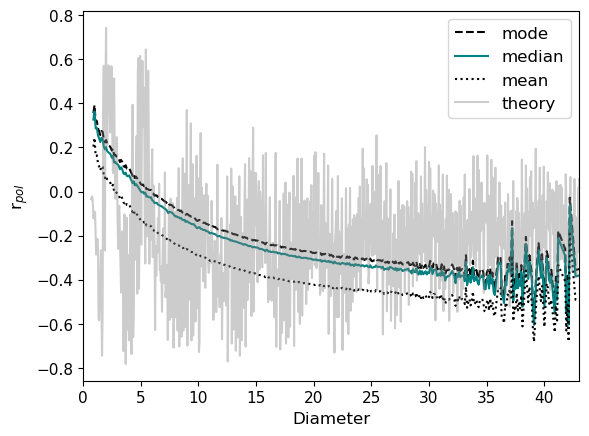

In [28]:
plt.plot(r_pol_mode.index, r_pol_mode['r_pol'], linestyle = '--', c = 'k', label = 'mode')
plt.plot(r_pol_median.index, r_pol_median['r_pol'],  c = 'teal', label = 'median')
plt.plot(r_pol_mean.index, r_pol_mean['r_pol'],  c = 'k', linestyle = ':',label = 'mean')
plt.plot(theory_rpol, alpha = 0.4 , color = 'grey', label = 'theory')
plt.legend(loc = 'upper right')
plt.ylabel('r$_{pol}$')
plt.xlabel('Diameter')
plt.xlim(0,43)

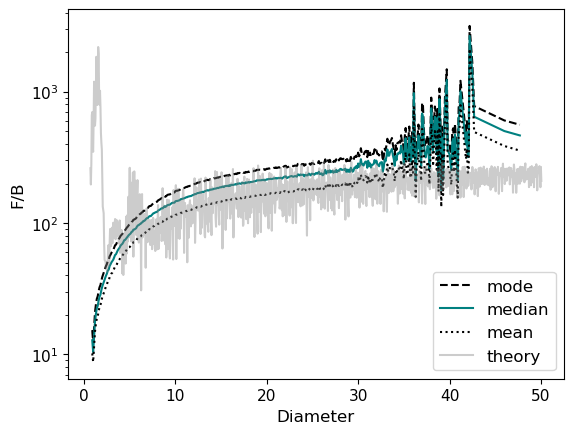

In [29]:
plt.plot(FB_mode.index, FB_mode['F/B'], linestyle = '--',  c = 'k', label = 'mode')
plt.plot(FB_median.index, FB_median['F/B'],  c = 'teal',label = 'median')
plt.plot(FB_mean.index, FB_mean['F/B'],  c = 'k', linestyle = ':',label = 'mean')
plt.plot(theory_FB, alpha = 0.4, color = 'grey', label = 'theory')
plt.ylabel('F/B')
plt.xlabel('Diameter')
plt.yscale('log')
plt.legend()

In [30]:
print("best scaling factor for P-pol: ", c_p_described['50%'])

best scaling factor for P-pol:  5.4954016214149664e-12


In [31]:
print("best scaling factor for S-pol: ", c_s_described['50%'])

best scaling factor for S-pol:  1.9382092806307163e-11


In [38]:
aII_cp = c_p_described
aII_cp

count    1.760949e+06
mean     7.725626e-12
std      2.416522e-11
min      8.247846e-14
25%      3.918853e-12
50%      5.495402e-12
75%      7.957176e-12
max      5.983365e-09
dtype: float64

In [39]:
aII_cs = c_s_described
aII_cs

count    1.760949e+06
mean     2.091529e-11
std      1.079182e-11
min      4.546121e-13
25%      1.391772e-11
50%      1.938209e-11
75%      2.591053e-11
max      1.450969e-09
dtype: float64

## Autocalibration III: Fit backward detectors via size distributions

In [34]:
# overall KS tests

nudge_P = (np.arange(6.0e-12,6.5e-12,0.02e-12)) #np.arange(5e-12, 0.7e-11, 0.1e-12)
nudge_S = (np.arange(1.95e-11, 2.2e-11, 0.02e-12)) #np.arange(1.3e-11, 1.7e-11, 0.1e-12)

d1 = wick['Diameter'].values
mask1 = np.isfinite(d1)
d1 = d1[mask1]


li_p = []
for i in range(len(nudge_P)):
    # sizing P detector
    assumed_sf = nudge_P[i]
    wick_p = pd.DataFrame(wick['P Peak'][wick['P Peak']>0]*assumed_sf).dropna()
    predict_P = poly_P.transform(np.log10(wick_p))
    p_diam = 10**clf_P.predict(predict_P)
    mask2 = np.isfinite(p_diam)
    d2 = p_diam[mask2]
   
    ks_res = ks_2samp(d1,d2)
    li_p.append(ks_res)

li_s = []
for i in range(len(nudge_S)):
    # sizing S detector
    assumed_sf = nudge_S[i]
    wick_s = pd.DataFrame(wick['S Peak'][wick['S Peak']>0]*assumed_sf).dropna()
    predict_S = poly_S.transform(np.log10(wick_s))
    s_diam = 10**clf_S.predict(predict_S)
    
    mask2 = np.isfinite(s_diam)
    d2 = s_diam[mask2]
   
    ks_res = ks_2samp(d1,d2)
    li_s.append(ks_res)


/home/leha7253/.conda/envs/mainenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/leha7253/.conda/envs/mainenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/leha7253/.conda/envs/mainenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/leha7253/.conda/envs/mainenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/leha7253/.conda/envs/mainenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without featur

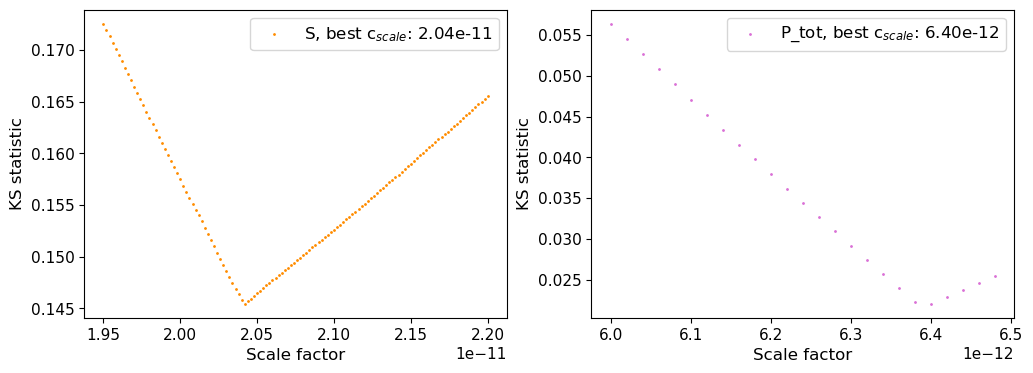

In [35]:
P_tot = pd.DataFrame({
    'statistic': [r.statistic for r in li_p],
    'pvalue':    [r.pvalue for r in li_p],
    'loc':       [r.statistic_location for r in li_p],
    'sign':     [r.statistic_sign for r in li_p]
}, index = nudge_P)

S_tot = pd.DataFrame({
    'statistic': [r.statistic for r in li_s],
    'pvalue':    [r.pvalue for r in li_s],
    'loc':       [r.statistic_location for r in li_s],
    'sign':     [r.statistic_sign for r in li_s]
}, index = nudge_S)
fig, ax = plt.subplots(1,2, figsize =(12,4))
ax[0].scatter(S_tot.index, S_tot['statistic'],s=1, label = f'S, best c$_{{scale}}$: {S_tot["statistic"].idxmin():.2e}', c = 'darkorange', )
ax[1].scatter(P_tot.index, P_tot['statistic'],s=1, label = f'P_tot, best c$_{{scale}}$: {P_tot["statistic"].idxmin():.2e}', c = 'orchid', )
#ax[0].vlines(S_tot["statistic"].idxmin(), 0.2,0.25,  color = 'darkorange',linewidth = 0.5, linestyle='--')
#ax[1].vlines(P_tot["statistic"].idxmin(), 0.05,0.1, color = 'orchid',linewidth = 0.5, linestyle='--')
ax[0].set_ylabel('KS statistic')
ax[1].set_ylabel('KS statistic')
ax[0].set_xlabel('Scale factor')
ax[1].set_xlabel('Scale factor')

ax[0].legend()
ax[1].legend()

P_tot.to_csv('detector_scaling_stats/P_total_KS_results.csv')
S_tot.to_csv('detector_scaling_stats/S_total_KS_results.csv')

In [40]:
# iterate over subgroups of particles to see differences in scaling factors
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)
nudge_P = np.arange(4e-12, 8e-12, 0.1e-12)
nudge_S = np.arange(0.5e-11, 2.5e-11, 0.5e-12)

min_ks_p = []
min_ks_s = []

for k in range(295):

    try:

        w = wick.iloc[k*9000:(k+1)*9000]

        # reference diameter distribution
        d1 = w["Diameter"].to_numpy()
        d1 = d1[np.isfinite(d1)]

        # extract detector signals only once
        p_peak = w.loc[w["P Peak"] > 0, "P Peak"].to_numpy()
        s_peak = w.loc[w["S Peak"] > 0, "S Peak"].to_numpy()

        # remove NaNs only once
        p_peak = p_peak[np.isfinite(p_peak)]
        s_peak = s_peak[np.isfinite(s_peak)]

        # precompute logarithms
        log_p_peak = np.log10(p_peak)
        log_s_peak = np.log10(s_peak)

        # ----------------------
        # P detector
        # ----------------------

        best_ks_p = np.inf #best KS statistic
        best_sf_p = np.nan #best scale factor

        for sf in nudge_P:

            X = (log_p_peak + np.log10(sf)).reshape(-1, 1)

            X_poly = poly_P.transform(X)
            p_diam = 10 ** clf_P.predict(X_poly)

            p_diam = p_diam[np.isfinite(p_diam)]

            ks = ks_2samp(d1, p_diam).statistic

            if ks < best_ks_p: # update best KS statistic and corresponding scale factor if current KS is better
                best_ks_p = ks
                best_sf_p = sf

        min_ks_p.append(best_sf_p)

        # ----------------------
        # S detector
        # ----------------------

        best_ks_s = np.inf
        best_sf_s = np.nan

        for sf in nudge_S:

            X = (log_s_peak + np.log10(sf)).reshape(-1, 1)

            X_poly = poly_S.transform(X)
            s_diam = 10 ** clf_S.predict(X_poly)

            s_diam = s_diam[np.isfinite(s_diam)]

            ks = ks_2samp(d1, s_diam).statistic

            if ks < best_ks_s:
                best_ks_s = ks
                best_sf_s = sf

        min_ks_s.append(best_sf_s)

    except Exception as e:
        print(f"error in group {k}: {e}")

    if (k + 1) % 10 == 0:
        print(f"{k+1} groups processed")

10 groups processed
20 groups processed
30 groups processed
40 groups processed
50 groups processed
60 groups processed
70 groups processed
80 groups processed
90 groups processed
100 groups processed
110 groups processed
120 groups processed
130 groups processed
140 groups processed
150 groups processed
160 groups processed
170 groups processed
180 groups processed
190 groups processed
error in group 197: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by PolynomialFeatures.
error in group 198: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by PolynomialFeatures.
error in group 199: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by PolynomialFeatures.
200 groups processed
error in group 200: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by PolynomialFeatures.
error in group 201: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by Polynomia

In [41]:
min_ks_p = pd.Series(min_ks_p)
min_ks_s = pd.Series(min_ks_s)
min_ks_p.to_csv('detector_scaling_stats/min_ks_p.csv')
min_ks_s.to_csv('detector_scaling_stats/min_ks_s.csv')

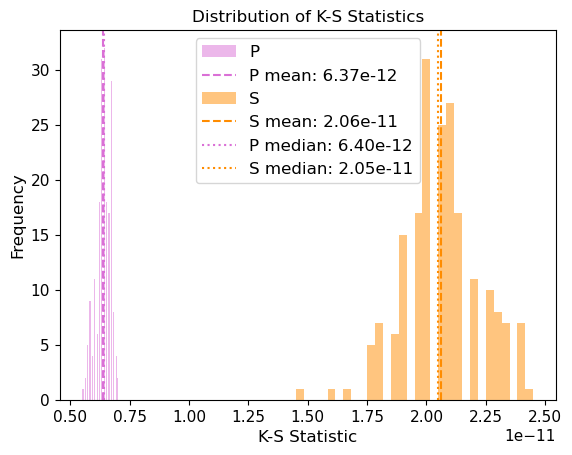

In [42]:
plt.hist(min_ks_p, bins = 30 ,color = 'orchid', alpha = 0.5, label = 'P')
# vline at mean
plt.axvline(np.mean(min_ks_p), color = 'orchid', linestyle = '--', label = f'P mean: {np.mean(min_ks_p):.2e}')
plt.hist(min_ks_s, bins = 30, color = 'darkorange', alpha = 0.5, label = 'S')
plt.axvline(np.mean(min_ks_s), color = 'darkorange', linestyle = '--', label = f'S mean: {np.mean(min_ks_s):.2e}')
plt.axvline(np.median(min_ks_p), color = 'orchid', linestyle = ':', label = f'P median: {np.median(min_ks_p):.2e}')
plt.axvline(np.median(min_ks_s), color = 'darkorange', linestyle = ':', label = f'S median: {np.median(min_ks_s):.2e}')
plt.xlabel('K-S Statistic')
plt.ylabel('Frequency')
plt.title('Distribution of K-S Statistics')
plt.legend()
plt.show()

In [43]:
c_p_described = min_ks_p.describe()
c_s_described =min_ks_s.describe()

### testing scale factors with $r_{pol}$ and $r_{F/B}$

In [44]:
S_peak =wick.loc[idx, 'S Peak']
P_peak =wick.loc[idx, 'P Peak']


meanS = S_peak*c_s_described['mean']
medianS = S_peak*c_s_described['50%']


meanP = P_peak*c_p_described['mean']
medianP = P_peak*c_p_described['50%']


r_pol_mean  = pd.DataFrame([(meanS-meanP)/(meanS+meanP), wick.loc[idx,'Diameter']], index = ['r_pol', 'Diameter']).T
r_pol_median  = pd.DataFrame([(medianS-medianP)/(medianS+medianP), wick.loc[idx,'Diameter']], index = ['r_pol', 'Diameter']).T

FB_mean  = pd.DataFrame([wick.loc[idx,'scaled Sizer Peak']/(meanS+meanP), wick.loc[idx,'Diameter']], index = ['F/B', 'Diameter']).T
FB_median  = pd.DataFrame([wick.loc[idx,'scaled Sizer Peak']/(medianS+medianP), wick.loc[idx,'Diameter']], index = ['F/B', 'Diameter']).T


In [45]:
bins = np.arange(0,50.1,0.1)
r_pol_mean['binned'] = pd.cut(r_pol_mean['Diameter'], bins = bins, labels = bins[1:])
r_pol_median['binned'] = pd.cut(r_pol_median['Diameter'], bins = bins, labels = bins[1:])


r_pol_mean = r_pol_mean.groupby('binned',observed = True).median()
r_pol_median = r_pol_median.groupby('binned',observed = True).median()


In [46]:

bins = np.arange(0,50.1,0.1)
FB_mean['binned'] = pd.cut(FB_mean['Diameter'], bins = bins, labels = bins[1:])
FB_median['binned'] = pd.cut(FB_median['Diameter'], bins = bins, labels = bins[1:])


FB_mean = FB_mean.groupby('binned',observed = True).median()
FB_median = FB_median.groupby('binned',observed = True).median()


(0.0, 43.0)

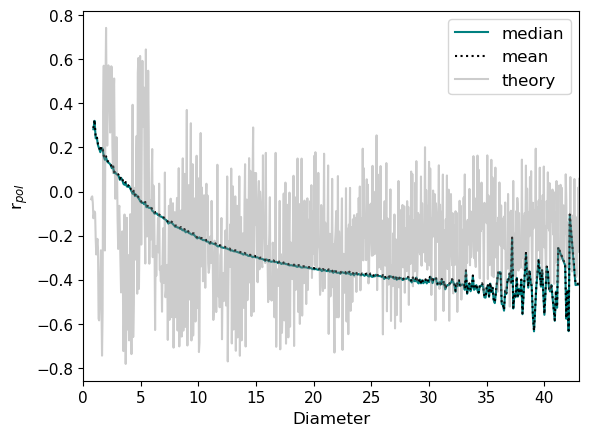

In [47]:
plt.plot(r_pol_median.index, r_pol_median['r_pol'],  c = 'teal', label = 'median')
plt.plot(r_pol_mean.index, r_pol_mean['r_pol'],  c = 'k', linestyle = ':',label = 'mean')
plt.plot(theory_rpol, alpha = 0.4 , color = 'grey', label = 'theory')
plt.legend(loc = 'upper right')
plt.ylabel('r$_{pol}$')
plt.xlabel('Diameter')
plt.xlim(0,43)

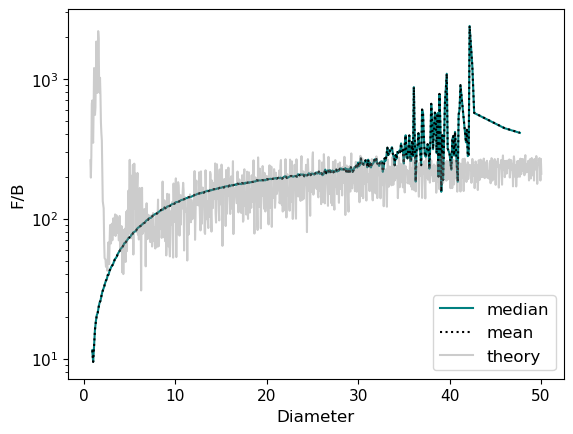

In [48]:
plt.plot(FB_median.index, FB_median['F/B'],  c = 'teal',label = 'median')
plt.plot(FB_mean.index, FB_mean['F/B'],  c = 'k', linestyle = ':',label = 'mean')
plt.plot(theory_FB, alpha = 0.4, color = 'grey', label = 'theory')
plt.ylabel('F/B')
plt.xlabel('Diameter')
plt.yscale('log')
plt.legend()

In [49]:
aIII_cs = c_s_described

In [53]:
aIII_cp = c_p_described

## finalize scale factors

In [54]:
# average scale factor from autocalibration II and III
p = (aIII_cp["50%"]+aII_cp["50%"])/2
s  = (aIII_cs['50%']+aII_cs['50%'])/2
print(f"scale factors $c_p$: {p:2e}, $c_s$: {s:2e}")

scale factors $c_p$: 5.947701e-12, $c_s$: 1.289105e-11


In [55]:
# update scale factors
scale_factors["S"] = s
scale_factors["P"] = p
scale_factors.to_csv("detector_scaling_factors")